# Inference Demo — Hybrid Knowledge Base

End-to-end inference on a **class-balanced sample** drawn from the real held-out test set.
Both trained ResNet-50 models classify each fundus image; the CNN prediction is then fused
with the patient's clinical metadata by the rule-based **Diabetic Retinopathy Triage Engine**.

| Grade | Label | Sample count |
|---|---|---|
| 0 | No DR | 10 |
| 1 | Mild NPDR | 10 |
| 2 | Moderate NPDR | 10 |
| 3 | Severe NPDR | 6 (all available) |
| 4 | PDR | 10 |
| **Total** | | **46** |

> **Data note:**  
> `sample_data/` contains 46 real fundus images sampled from the research dataset test split.
> Regenerate the sample at any time by running `generate_sample_data.py`.
> Check your dataset licence before pushing images to a public repository.

**Models required** (run notebooks 02 & 03 first to produce the weights):
```
models/best_method1_multiclass_resnet50.pth
models/best_method2_binary_resnet50.pth
models/best_method2_severity_resnet50.pth
```

**Pipeline:**
```
fundus image  ──► ResNet-50 (Method 1)  ──► 5-class grade
                                              │
              ──► ResNet-50 (Method 2)  ──── ▼
clinical CSV  ─────────────────────────► Triage Engine ──► action + rationale
```

## 1. Setup & Imports

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

Device : cuda
GPU    : NVIDIA GeForce RTX 3060 Laptop GPU


## 2. Configuration

In [19]:
CONFIG = {
    # ── class-balanced sample from real test set 
    'sample_csv':   'sample_data/sample_test.csv',
    'sample_images':'sample_data/images',
    # trained model weights 
    'method1_model_path':    'models/best_method1_multiclass_resnet50.pth',
    'method2_binary_path':   'models/best_method2_binary_resnet50.pth',
    'method2_severity_path': 'models/best_method2_severity_resnet50.pth',
    # inference settings 
    'img_size':    224,
    'batch_size':  16,
    'num_workers': 0,
    'use_amp':     True,
    # output 
    'images_dir':  'images',
}

DR_LABELS = {0: 'No DR', 1: 'Mild NPDR', 2: 'Moderate NPDR', 3: 'Severe NPDR', 4: 'PDR'}
AMP_ENABLED = CONFIG['use_amp'] and torch.cuda.is_available()
os.makedirs(CONFIG['images_dir'], exist_ok=True)

## 3. Load Sample Dataset

In [20]:
df = pd.read_csv(CONFIG['sample_csv'])
print(f'Sample set : {len(df)} images')
print()
print('DR grade distribution:')
for g, lbl in DR_LABELS.items():
    n = (df['DR_ICDR'] == g).sum()
    bar = '█' * n
    print(f'  Grade {g} ({lbl:>15}): {n:>3}  {bar}')
print()
print(df[['image_id','DR_ICDR','patient_age','diabetes_time_y',
          'insuline','quality','macular_edema']].head(8).to_string(index=False))

Sample set : 46 images

DR grade distribution:
  Grade 0 (          No DR):  10  ██████████
  Grade 1 (      Mild NPDR):  10  ██████████
  Grade 2 (  Moderate NPDR):  10  ██████████
  Grade 3 (    Severe NPDR):   6  ██████
  Grade 4 (            PDR):  10  ██████████

    image_id  DR_ICDR  patient_age  diabetes_time_y insuline  quality  macular_edema
img14340.jpg        0          NaN              NaN      NaN Adequate              0
img09877.jpg        0          NaN              NaN      NaN Adequate              0
img04933.jpg        0         79.0             10.0       no Adequate              0
img06311.jpg        0         44.0              NaN      NaN Adequate              0
img04881.jpg        0         69.0              NaN      NaN Adequate              0
img12450.jpg        0         10.0              NaN      NaN Adequate              0
img00596.jpg        0         72.0              NaN      NaN Adequate              0
img15933.jpg        0          NaN              NaN

## 4. Dataset & Model Utilities

In [21]:
class FundusDataset(Dataset):
    """Loads fundus images from a folder referenced by a CSV."""
    def __init__(self, dataframe, img_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        path  = os.path.join(self.img_dir, row['image_id'])
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = int(row['DR_ICDR'])
        return image, label


def build_resnet50(num_classes: int) -> nn.Module:
    m = models.resnet50(weights=None)
    m.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(m.fc.in_features, num_classes)
    )
    return m


test_transforms = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

dataset = FundusDataset(df, CONFIG['sample_images'], test_transforms)
loader  = DataLoader(dataset,
                     batch_size  = CONFIG['batch_size'],
                     shuffle     = False,
                     num_workers = CONFIG['num_workers'],
                     pin_memory  = (device.type == 'cuda'))

print(f'Dataset  : {len(dataset)} images')
print(f'Loader   : {len(loader)} batches of {CONFIG["batch_size"]}')

Dataset  : 46 images
Loader   : 3 batches of 16


## 5. Load Trained Models

In [22]:
def load_model(path, num_classes):
    m = build_resnet50(num_classes).to(device)
    m.load_state_dict(torch.load(path, map_location=device))
    m.eval()
    print(f'  Loaded {path}  ({num_classes}-class head)')
    return m


print('Loading models...')
model_m1       = load_model(CONFIG['method1_model_path'],    num_classes=5)
model_m2_bin   = load_model(CONFIG['method2_binary_path'],   num_classes=2)
model_m2_sev   = load_model(CONFIG['method2_severity_path'], num_classes=4)
print('All models ready.')

Loading models...
  Loaded models/best_method1_multiclass_resnet50.pth  (5-class head)
  Loaded models/best_method2_binary_resnet50.pth  (2-class head)
  Loaded models/best_method2_severity_resnet50.pth  (4-class head)
All models ready.


## 6. Run CNN Inference

In [23]:
m1_preds_list   = []
m1_probs_list   = []
m2_preds_list   = []
true_labels_list = []

with torch.no_grad(), torch.amp.autocast('cuda', enabled=AMP_ENABLED):
    for images, labels in tqdm(loader, desc='Inference'):
        images = images.to(device, non_blocking=True)

        # Method 1: single 5-class head
        logits_m1 = model_m1(images)
        probs_m1  = torch.softmax(logits_m1, dim=1)
        m1_preds_list.extend(probs_m1.argmax(1).cpu().numpy())
        m1_probs_list.append(probs_m1.cpu().numpy())

        #  Method 2: binary → severity pipeline 
        bin_pred   = model_m2_bin(images).argmax(1)
        batch_pred = torch.zeros_like(bin_pred)
        mal_mask   = bin_pred == 1
        if mal_mask.any():
            sev_pred = model_m2_sev(images[mal_mask]).argmax(1)
            batch_pred[mal_mask] = sev_pred + 1
        m2_preds_list.extend(batch_pred.cpu().numpy())

        true_labels_list.extend(labels.numpy())

m1_preds   = np.array(m1_preds_list)
m1_probs   = np.vstack(m1_probs_list)
m2_preds   = np.array(m2_preds_list)
true_labels = np.array(true_labels_list)

print(f'\nInference complete on {len(true_labels)} images.')
print(f'Method 1 accuracy (sample): {(m1_preds == true_labels).mean():.2%}')
print(f'Method 2 accuracy (sample): {(m2_preds == true_labels).mean():.2%}')

Inference: 100%|██████████| 3/3 [00:00<00:00,  3.67it/s]


Inference complete on 46 images.
Method 1 accuracy (sample): 63.04%
Method 2 accuracy (sample): 60.87%


## 7. Sample Image Grid  Predictions vs. Ground Truth

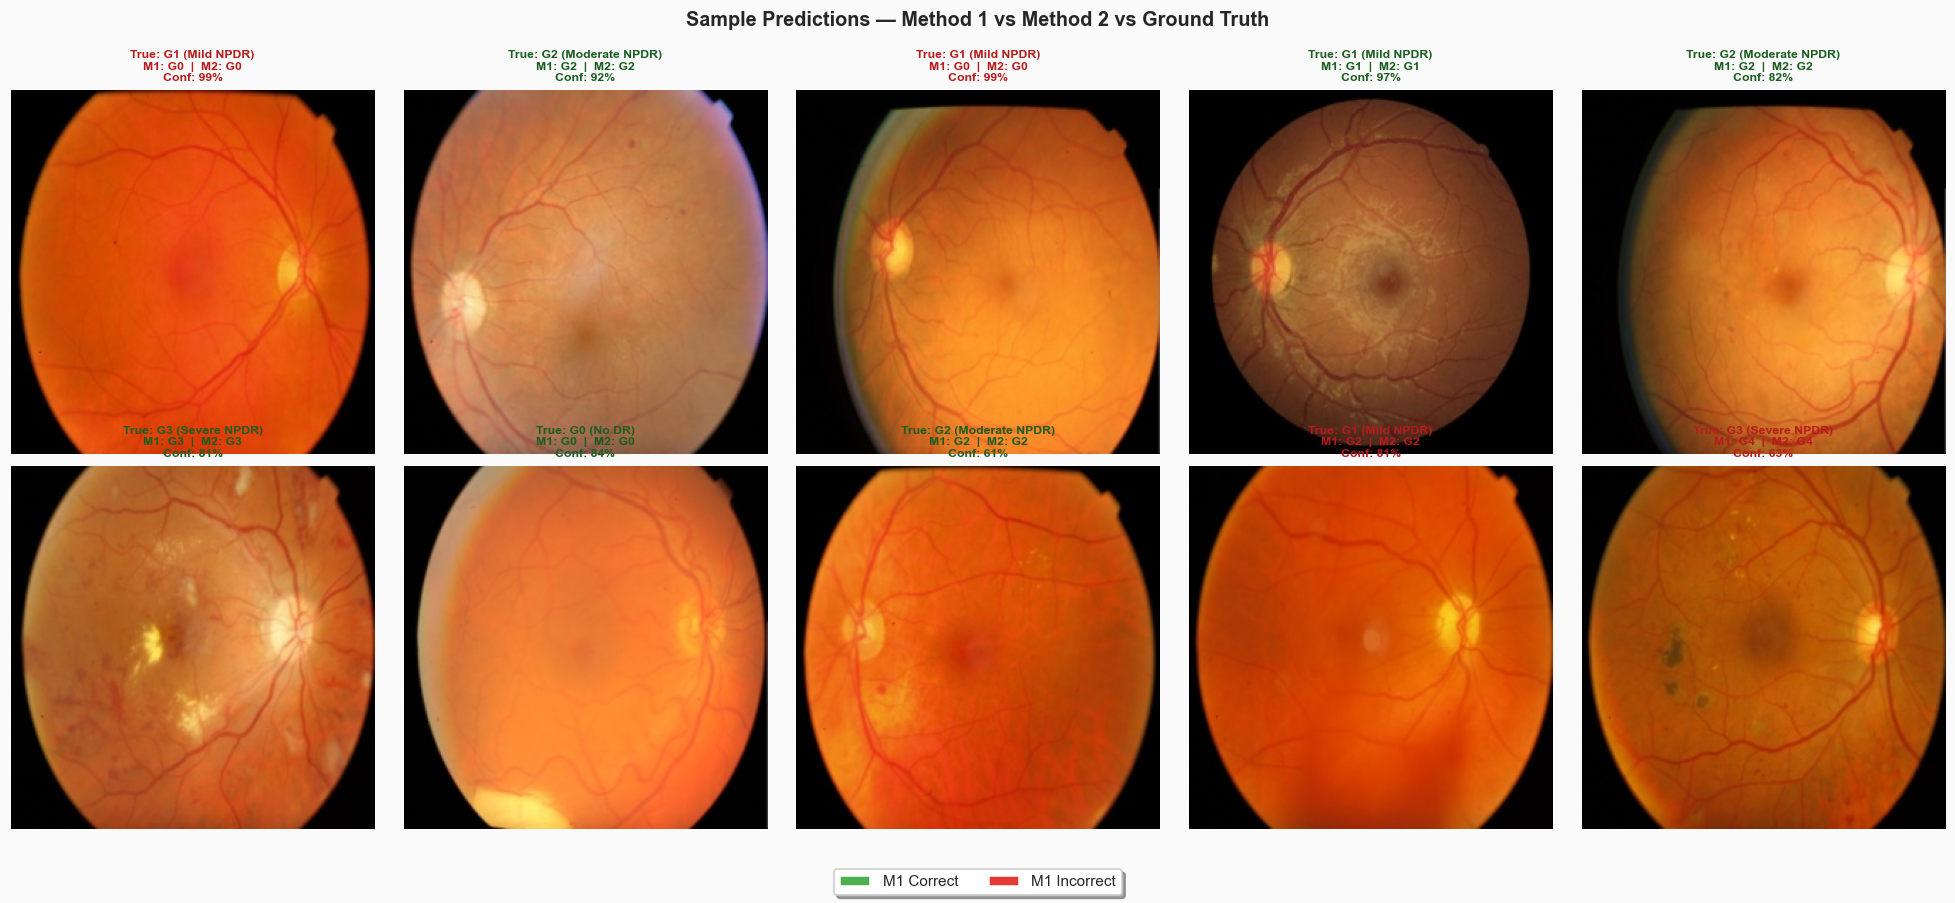

Saved: images/inference_sample_grid.png


In [24]:
GRADE_COLORS = {0: '#4CAF50', 1: '#8BC34A', 2: '#FFC107', 3: '#FF5722', 4: '#B71C1C'}

np.random.seed(7)
sample_idx = np.random.choice(len(df), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.patch.set_facecolor('#FAFAFA')
for ax, idx in zip(axes.flat, sample_idx):
    row  = df.iloc[idx]
    img  = Image.open(os.path.join(CONFIG['sample_images'], row['image_id']))
    true_g = int(row['DR_ICDR'])
    m1_g   = int(m1_preds[idx])
    m2_g   = int(m2_preds[idx])

    ax.imshow(img)
    ax.axis('off')

    correct = m1_g == true_g
    edge_color = '#4CAF50' if correct else '#E53935'
    for spine in ax.spines.values():
        spine.set_edgecolor(edge_color)
        spine.set_linewidth(4)
    ax.spines[:].set_visible(True)

    conf = m1_probs[idx].max() * 100
    title = (f'True: G{true_g} ({DR_LABELS[true_g]})\n'
             f'M1: G{m1_g}  |  M2: G{m2_g}\n'
             f'Conf: {conf:.0f}%')
    color = '#1B5E20' if correct else '#B71C1C'
    ax.set_title(title, fontsize=8, fontweight='bold', color=color)

legend_patches = [
    mpatches.Patch(facecolor='#4CAF50', edgecolor='white', label='M1 Correct'),
    mpatches.Patch(facecolor='#E53935', edgecolor='white', label='M1 Incorrect'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=2, fontsize=10,
           frameon=True, fancybox=True, shadow=True)
plt.suptitle('Sample Predictions — Method 1 vs Method 2 vs Ground Truth',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.savefig('images/inference_sample_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/inference_sample_grid.png')

## 8. Confidence Heatmap (Method 1 Softmax Probabilities)

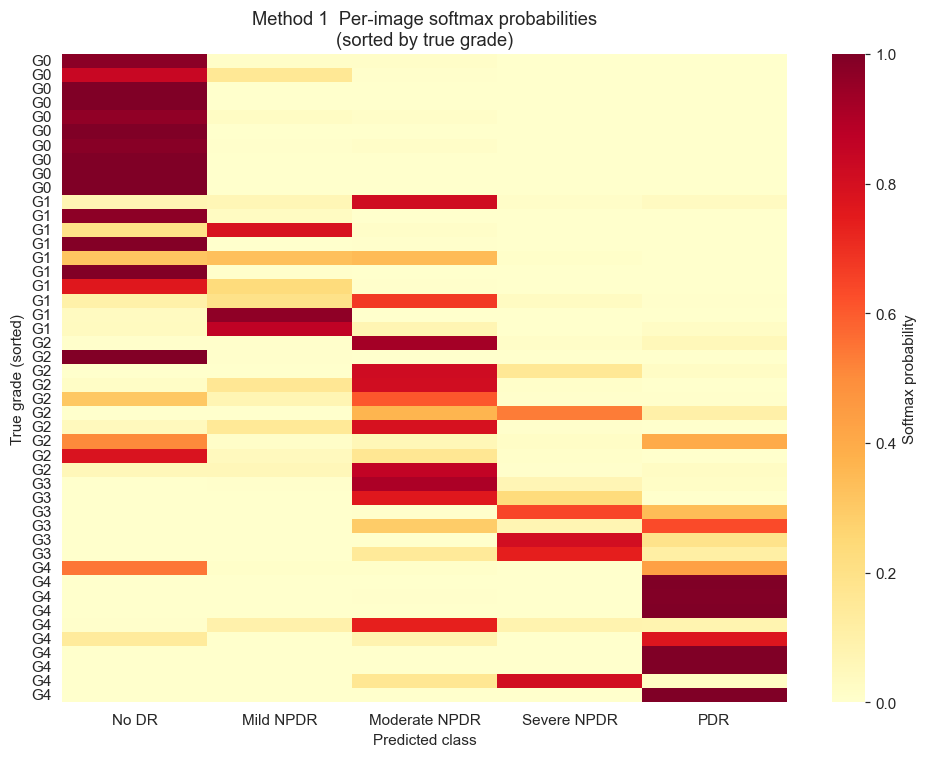

Saved: images/inference_confidence_heatmap.png


In [25]:
# Sort samples by true grade for a cleaner heatmap
sort_idx   = np.argsort(true_labels)
probs_sorted = m1_probs[sort_idx]
labels_sorted = true_labels[sort_idx]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(probs_sorted, cmap='YlOrRd', vmin=0, vmax=1,
            xticklabels=list(DR_LABELS.values()),
            yticklabels=[f'G{g}' for g in labels_sorted],
            ax=ax, cbar_kws={'label': 'Softmax probability'})
ax.set_xlabel('Predicted class')
ax.set_ylabel('True grade (sorted)')
ax.set_title('Method 1  Per-image softmax probabilities\n(sorted by true grade)')
plt.tight_layout()
plt.savefig('images/inference_confidence_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/inference_confidence_heatmap.png')

## 8b. Confusion Matrices Method 1 vs Method 2

Side-by-side confusion matrices showing where each method agrees/disagrees with the ground truth on the synthetic sample data.

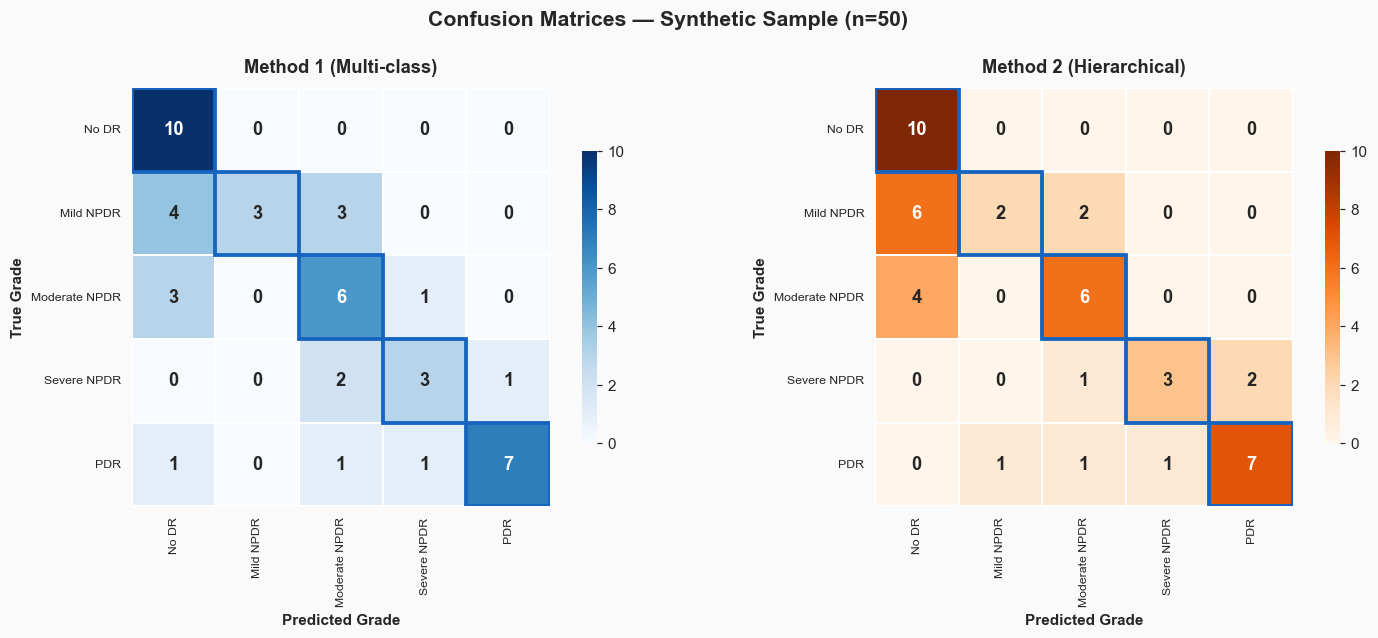

METHOD 1 — Classification Report
               precision    recall  f1-score   support

        No DR       0.56      1.00      0.71        10
    Mild NPDR       1.00      0.30      0.46        10
Moderate NPDR       0.50      0.60      0.55        10
  Severe NPDR       0.60      0.50      0.55         6
          PDR       0.88      0.70      0.78        10

     accuracy                           0.63        46
    macro avg       0.71      0.62      0.61        46
 weighted avg       0.72      0.63      0.61        46


METHOD 2 — Classification Report
               precision    recall  f1-score   support

        No DR       0.50      1.00      0.67        10
    Mild NPDR       0.67      0.20      0.31        10
Moderate NPDR       0.60      0.60      0.60        10
  Severe NPDR       0.75      0.50      0.60         6
          PDR       0.78      0.70      0.74        10

     accuracy                           0.61        46
    macro avg       0.66      0.60      0.58    

In [26]:
from sklearn.metrics import confusion_matrix, classification_report

grade_names = list(DR_LABELS.values())
cm_m1 = confusion_matrix(true_labels, m1_preds, labels=list(range(5)))
cm_m2 = confusion_matrix(true_labels, m2_preds, labels=list(range(5)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor('#FAFAFA')

for ax, cm, title, cmap in [(ax1, cm_m1, 'Method 1 (Multi-class)', 'Blues'),
                              (ax2, cm_m2, 'Method 2 (Hierarchical)', 'Oranges')]:
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, linewidths=1, linecolor='white',
                xticklabels=grade_names, yticklabels=grade_names,
                square=True, cbar_kws={'shrink': 0.7}, ax=ax,
                annot_kws={'fontsize': 12, 'fontweight': 'bold'})
    ax.set_xlabel('Predicted Grade', fontsize=10, fontweight='bold')
    ax.set_ylabel('True Grade', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.tick_params(axis='both', labelsize=8)

    # highlight diagonal
    for i in range(min(cm.shape)):
        ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False,
                                    edgecolor='#1565C0', linewidth=2.5))

plt.suptitle('Confusion Matrices — Synthetic Sample (n=50)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/inference_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification reports
print('=' * 65)
print('METHOD 1 — Classification Report')
print('=' * 65)
print(classification_report(true_labels, m1_preds, target_names=grade_names, zero_division=0))
print()
print('=' * 65)
print('METHOD 2 — Classification Report')
print('=' * 65)
print(classification_report(true_labels, m2_preds, target_names=grade_names, zero_division=0))
print('\nSaved: images/inference_confusion_matrices.png')

## 8c. Method Agreement & Per-Class Accuracy Comparison

How often do Method 1 and Method 2 agree with each other, and how does per-class accuracy compare across the two approaches?

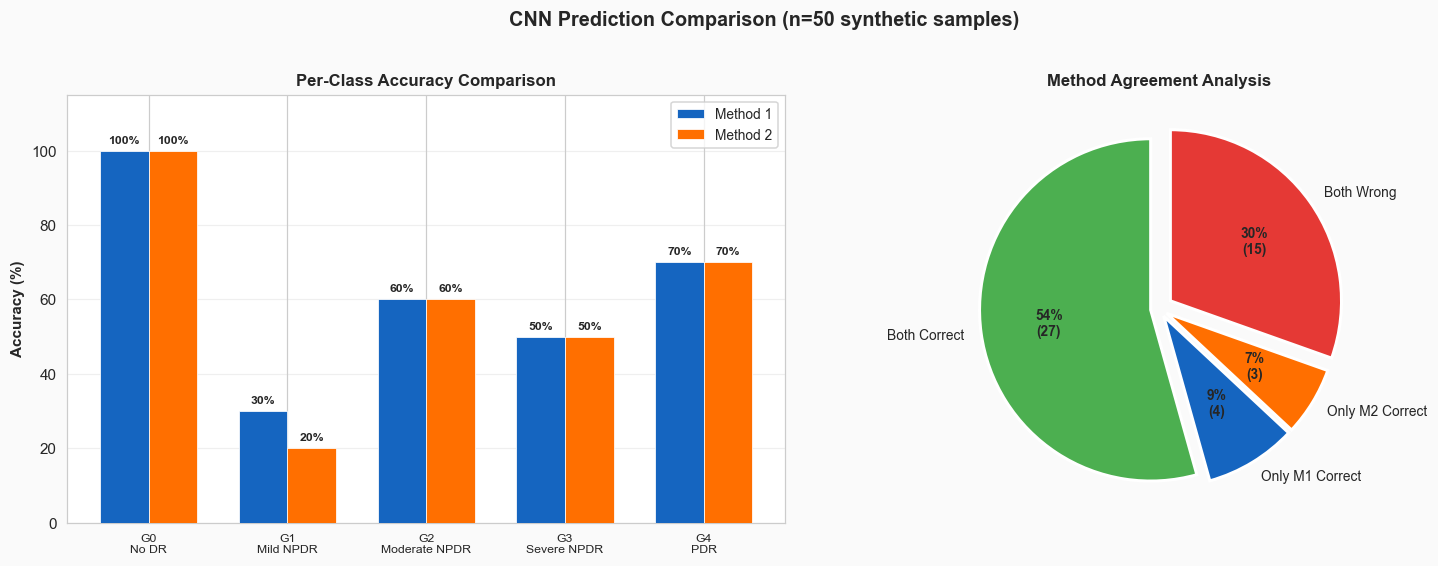

Agreement rate (both methods same prediction): 82.6%
Saved: images/inference_method_agreement.png


In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#FAFAFA')

# ── Left: Per-class accuracy grouped bar ──────────────────────────────────
per_class_m1 = []
per_class_m2 = []
for g in range(5):
    mask = true_labels == g
    if mask.sum() > 0:
        per_class_m1.append((m1_preds[mask] == g).mean() * 100)
        per_class_m2.append((m2_preds[mask] == g).mean() * 100)
    else:
        per_class_m1.append(0)
        per_class_m2.append(0)

x = np.arange(5)
w = 0.35
bars1 = ax1.bar(x - w/2, per_class_m1, w, label='Method 1', color='#1565C0',
                edgecolor='white', linewidth=0.5, zorder=3)
bars2 = ax1.bar(x + w/2, per_class_m2, w, label='Method 2', color='#FF6F00',
                edgecolor='white', linewidth=0.5, zorder=3)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., h + 1.5, f'{h:.0f}%',
                 ha='center', va='bottom', fontsize=8, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels([f'G{g}\n{DR_LABELS[g]}' for g in range(5)], fontsize=8)
ax1.set_ylabel('Accuracy (%)', fontweight='bold')
ax1.set_title('Per-Class Accuracy Comparison', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 115)
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(axis='y', alpha=0.3, zorder=0)

# ── Right: Agreement pie chart ────────────────────────────────────────────
both_correct   = ((m1_preds == true_labels) & (m2_preds == true_labels)).sum()
m1_only        = ((m1_preds == true_labels) & (m2_preds != true_labels)).sum()
m2_only        = ((m1_preds != true_labels) & (m2_preds == true_labels)).sum()
both_wrong     = ((m1_preds != true_labels) & (m2_preds != true_labels)).sum()

labels_pie = ['Both Correct', 'Only M1 Correct', 'Only M2 Correct', 'Both Wrong']
sizes = [both_correct, m1_only, m2_only, both_wrong]
colors_pie = ['#4CAF50', '#1565C0', '#FF6F00', '#E53935']
explode = (0.05, 0.05, 0.05, 0.08)

wedges, texts, autotexts = ax2.pie(
    sizes, explode=explode, labels=labels_pie, colors=colors_pie,
    autopct=lambda p: f'{p:.0f}%\n({int(round(p*50/100))})',
    startangle=90, textprops={'fontsize': 9},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2})
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(9)
ax2.set_title('Method Agreement Analysis', fontsize=11, fontweight='bold')

plt.suptitle('CNN Prediction Comparison (n=50 synthetic samples)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/inference_method_agreement.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Agreement rate (both methods same prediction): {(m1_preds == m2_preds).mean():.1%}')
print(f'Saved: images/inference_method_agreement.png')

---
# Knowledge Base Triage Engine
---

## 9. Triage Engine Definition

In [28]:
class DiabeticRetinopathyTriageEngine:
    """
    Hybrid Knowledge Base — fuses CNN image grading with structured
    clinical metadata to produce explainable triage decisions.

    Clinical risk categories:
      HIGH     — dialysis / kidney disease / very long diabetes / multiple risk factors
      MODERATE — hypertension or dyslipidemia, moderate duration
      LOW      — no major systemic risk factors
    """

    def calculate_tabular_risk(
            self, age, duration, uses_insulin,
            has_hypertension, has_dyslipidemia,
            has_kidney_disease, on_dialysis):
        if has_kidney_disease or on_dialysis:
            return 'HIGH'
        if duration > 15.5:
            return 'HIGH'
        if duration > 11.5 and uses_insulin and age > 18.5:
            return 'HIGH'
        if has_hypertension and has_dyslipidemia and uses_insulin:
            return 'HIGH'
        if has_hypertension or has_dyslipidemia:
            return 'MODERATE'
        if duration > 5.5 and uses_insulin and age > 18.5:
            return 'MODERATE'
        return 'LOW'

    def evaluate_triage(
            self, cnn_grade, macular_edema, quality,
            age, duration, uses_insulin,
            has_hypertension, has_dyslipidemia,
            has_kidney_disease, on_dialysis):

        if str(quality).lower() == 'inadequate':
            return {'action': 'RETAKE IMAGE', 'urgency_level': 0,
                    'tabular_risk': 'N/A',
                    'rationale': 'Image quality inadequate for reliable classification.'}

        tabular_risk = self.calculate_tabular_risk(
            age, duration, uses_insulin,
            has_hypertension, has_dyslipidemia,
            has_kidney_disease, on_dialysis)

        if cnn_grade >= 3 or macular_edema:
            return {'action': 'URGENT REFERRAL', 'urgency_level': 3,
                    'tabular_risk': tabular_risk,
                    'rationale': (
                        f'Critical damage detected (Grade {cnn_grade}'
                        + (' + Macular Edema' if macular_edema else '')
                        + '). Immediate specialist intervention required.')}

        if cnn_grade == 2:
            if tabular_risk == 'HIGH':
                return {'action': 'PRIORITY REFERRAL', 'urgency_level': 2,
                        'tabular_risk': tabular_risk,
                        'rationale': 'Moderate DR aggravated by high systemic risk. Escalated priority.'}
            return {'action': 'ROUTINE REFERRAL', 'urgency_level': 1,
                    'tabular_risk': tabular_risk,
                    'rationale': 'Moderate DR detected. Standard specialist evaluation needed.'}

        if cnn_grade == 1:
            if tabular_risk == 'HIGH':
                return {'action': 'ROUTINE REFERRAL', 'urgency_level': 1,
                        'tabular_risk': tabular_risk,
                        'rationale': 'Mild DR with high systemic risk — proactive specialist review needed.'}
            if tabular_risk == 'MODERATE':
                return {'action': 'LOCAL MONITORING', 'urgency_level': 1,
                        'tabular_risk': tabular_risk,
                        'rationale': 'Mild DR aggravated by cardiovascular risk factors. 6-month follow-up.'}
            return {'action': 'LOCAL MONITORING', 'urgency_level': 0,
                    'tabular_risk': tabular_risk,
                    'rationale': 'Mild DR in a well-controlled patient. 12-month follow-up.'}

        # Grade 0 — no DR
        if tabular_risk == 'HIGH':
            return {'action': 'VIGILANCE SCREENING', 'urgency_level': 0,
                    'tabular_risk': tabular_risk,
                    'rationale': 'Retina healthy but systemic risk is high — 6-month screening recommended.'}
        return {'action': 'ANNUAL SCREENING', 'urgency_level': 0,
                'tabular_risk': tabular_risk,
                'rationale': 'Retina healthy, systemic health stable. Standard yearly checkup.'}


triage_engine = DiabeticRetinopathyTriageEngine()
print('Triage engine ready.')

Triage engine ready.


## 10. Extract Clinical Features

In [29]:
def extract_clinical_features(df):
    """Parse raw CSV columns into the features the triage engine expects."""
    feat = pd.DataFrame(index=df.index)

    feat['age']      = pd.to_numeric(df['patient_age'], errors='coerce').fillna(50.0)
    feat['duration'] = pd.to_numeric(df['diabetes_time_y'], errors='coerce').fillna(0.0)
    feat['uses_insulin'] = df['insuline'].apply(lambda x: str(x).strip().lower() == 'yes')

    comorbid = df['comorbidities'].fillna('').str.lower()
    feat['has_hypertension']  = (
        comorbid.str.contains('hypertension', na=False) |
        (df['hypertensive_retinopathy'] == 1)
    )
    feat['has_dyslipidemia']  = comorbid.str.contains(
        'dyslipidemia|hypercholesterolemia|hyperlipidemia', na=False)
    feat['has_kidney_disease'] = comorbid.str.contains('kidney|renal|nephro', na=False)
    feat['on_dialysis']        = comorbid.str.contains('dialysis', na=False)
    feat['quality']            = df['quality']
    feat['macular_edema']      = df['macular_edema'] == 1
    return feat


clinical = extract_clinical_features(df)
print(f'Clinical features ready for {len(clinical)} patients.')
print(f'  Insulin users    : {clinical["uses_insulin"].sum()}')
print(f'  Hypertension     : {clinical["has_hypertension"].sum()}')
print(f'  Dyslipidemia     : {clinical["has_dyslipidemia"].sum()}')
print(f'  Kidney disease   : {clinical["has_kidney_disease"].sum()}')
print(f'  Macular edema    : {clinical["macular_edema"].sum()}')
print(f'  Inadequate quality: {(clinical["quality"] == "Inadequate").sum()}')

Clinical features ready for 46 patients.
  Insulin users    : 18
  Hypertension     : 15
  Dyslipidemia     : 1
  Kidney disease   : 0
  Macular edema    : 14
  Inadequate quality: 4


## 11. Run Hybrid Triage (Method 1 + Method 2 + Ground Truth)

In [30]:
def run_hybrid_triage(cnn_preds, clinical_df, engine):
    decisions = []
    for i in range(len(cnn_preds)):
        row = clinical_df.iloc[i]
        d   = engine.evaluate_triage(
            cnn_grade        = int(cnn_preds[i]),
            macular_edema    = bool(row['macular_edema']),
            quality          = row['quality'],
            age              = float(row['age']),
            duration         = float(row['duration']),
            uses_insulin     = bool(row['uses_insulin']),
            has_hypertension  = bool(row['has_hypertension']),
            has_dyslipidemia  = bool(row['has_dyslipidemia']),
            has_kidney_disease= bool(row['has_kidney_disease']),
            on_dialysis       = bool(row['on_dialysis']),
        )
        decisions.append(d)
    return pd.DataFrame(decisions)


triage_m1 = run_hybrid_triage(m1_preds,    clinical, triage_engine)
triage_m2 = run_hybrid_triage(m2_preds,    clinical, triage_engine)
triage_gt = run_hybrid_triage(true_labels, clinical, triage_engine)

print('Triage decisions generated for all 50 sample patients.')

Triage decisions generated for all 50 sample patients.


## 12. Triage Action Distribution

=== Triage Action Counts ===
              ANNUAL SCREENING  VIGILANCE SCREENING  LOCAL MONITORING  ROUTINE REFERRAL  PRIORITY REFERRAL  URGENT REFERRAL  RETAKE IMAGE
Source                                                                                                                                   
Ground Truth                10                    0                 4                 7                  2               19             4
Method 1                    15                    2                 1                 3                  3               18             4
Method 2                    17                    2                 0                 3                  3               17             4



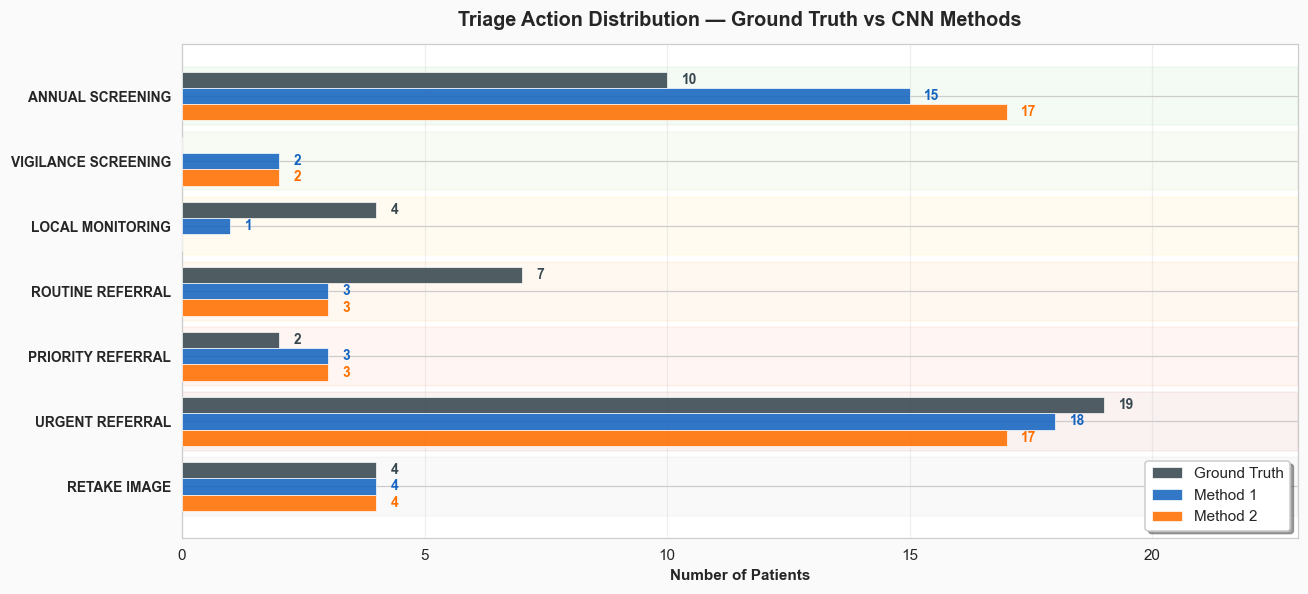

Saved: images/inference_triage_distribution.png


In [31]:
ACTION_ORDER = [
    'ANNUAL SCREENING', 'VIGILANCE SCREENING', 'LOCAL MONITORING',
    'ROUTINE REFERRAL', 'PRIORITY REFERRAL', 'URGENT REFERRAL', 'RETAKE IMAGE'
]
ACTION_COLORS = {
    'ANNUAL SCREENING':     '#4CAF50',
    'VIGILANCE SCREENING':  '#8BC34A',
    'LOCAL MONITORING':     '#FFC107',
    'ROUTINE REFERRAL':     '#FF9800',
    'PRIORITY REFERRAL':    '#FF5722',
    'URGENT REFERRAL':      '#B71C1C',
    'RETAKE IMAGE':         '#9E9E9E',
}

def action_row(triage_df, label):
    c = triage_df['action'].value_counts()
    row = {a: int(c.get(a, 0)) for a in ACTION_ORDER}
    row['Source'] = label
    return row

dist_df = pd.DataFrame([
    action_row(triage_gt, 'Ground Truth'),
    action_row(triage_m1, 'Method 1'),
    action_row(triage_m2, 'Method 2'),
]).set_index('Source')

print('=== Triage Action Counts ===')
print(dist_df.to_string())
print()

# ── Grouped horizontal bar chart ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5.5))
fig.patch.set_facecolor('#FAFAFA')

y = np.arange(len(ACTION_ORDER))
h = 0.25
sources = ['Ground Truth', 'Method 1', 'Method 2']
src_colors = ['#37474F', '#1565C0', '#FF6F00']

for i, (src, clr) in enumerate(zip(sources, src_colors)):
    vals = [dist_df.loc[src, a] for a in ACTION_ORDER]
    bars = ax.barh(y + (i - 1) * h, vals, h, label=src, color=clr,
                   edgecolor='white', linewidth=0.5, zorder=3, alpha=0.88)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                    str(v), va='center', fontsize=9, fontweight='bold', color=clr)

ax.set_yticks(y)
ax.set_yticklabels(ACTION_ORDER, fontsize=9, fontweight='bold')
ax.set_xlabel('Number of Patients', fontsize=10, fontweight='bold')
ax.set_title('Triage Action Distribution — Ground Truth vs CNN Methods',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10, loc='lower right', frameon=True, fancybox=True, shadow=True)
ax.grid(axis='x', alpha=0.3, zorder=0)
ax.set_xlim(0, dist_df.values.max() + 4)
ax.invert_yaxis()

# colour-coded urgency bands
for i, action in enumerate(ACTION_ORDER):
    ax.axhspan(i - 0.45, i + 0.45, alpha=0.06, color=ACTION_COLORS[action], zorder=0)

plt.tight_layout()
plt.savefig('images/inference_triage_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/inference_triage_distribution.png')

## 13. Per-Patient Inference Report (first 15 patients)

In [ ]:
print(f'{"Patient":<30} {"True":^14} {"M1 grade":^9} {"M2 grade":^9} '
      f'{"M1 Action":<22} {"Risk":<10} Rationale')
print('-' * 130)
for i in range(min(15, len(df))):
    row  = df.iloc[i]
    tg   = int(row['DR_ICDR'])
    m1g  = int(m1_preds[i])
    m2g  = int(m2_preds[i])
    act  = triage_m1.iloc[i]['action']
    risk = triage_m1.iloc[i]['tabular_risk']
    rat  = triage_m1.iloc[i]['rationale']
    urg  = triage_m1.iloc[i]['urgency_level']
    print(f'{row["image_id"]:<30} '
          f'{DR_LABELS[tg]:^14} '
          f'{DR_LABELS[m1g]:^9} '
          f'{DR_LABELS[m2g]:^9} '
          f'{risk:<10} '
          f'{rat[:60]}')

Patient                             True      M1 grade  M2 grade  M1 Action              Risk       Rationale
----------------------------------------------------------------------------------------------------------------------------------
img14340.jpg                       No DR        No DR     No DR   LOW        Retina healthy, systemic health stable. Standard yearly chec
img09877.jpg                       No DR        No DR     No DR   LOW        Retina healthy, systemic health stable. Standard yearly chec
img04933.jpg                       No DR        No DR     No DR   MODERATE   Retina healthy, systemic health stable. Standard yearly chec
img06311.jpg                       No DR        No DR     No DR   LOW        Retina healthy, systemic health stable. Standard yearly chec
img04881.jpg                       No DR        No DR     No DR   LOW        Retina healthy, systemic health stable. Standard yearly chec
img12450.jpg                       No DR        No DR     No DR   LOW

## 14. Save Full Inference Results to CSV

In [34]:
results_df = df[['image_id', 'DR_ICDR']].copy()
results_df['true_label_name']   = results_df['DR_ICDR'].map(DR_LABELS)
results_df['m1_pred']           = m1_preds
results_df['m1_pred_name']      = results_df['m1_pred'].map(DR_LABELS)
results_df['m2_pred']           = m2_preds
results_df['m2_pred_name']      = results_df['m2_pred'].map(DR_LABELS)
results_df['m1_action']         = triage_m1['action'].values
results_df['m1_tabular_risk']   = triage_m1['tabular_risk'].values
results_df['m1_urgency_level']  = triage_m1['urgency_level'].values
results_df['m1_rationale']      = triage_m1['rationale'].values
results_df['m2_action']         = triage_m2['action'].values
results_df['gt_action']         = triage_gt['action'].values

out_path = 'sample_data/inference_results.csv'
results_df.to_csv(out_path, index=False)
print(f'Results saved to {out_path}')
print()
print(results_df[['image_id','true_label_name','m1_pred_name',
                  'm1_action','m1_tabular_risk']].head(10).to_string(index=False))

Results saved to sample_data/inference_results.csv

    image_id true_label_name m1_pred_name        m1_action m1_tabular_risk
img14340.jpg           No DR        No DR ANNUAL SCREENING             LOW
img09877.jpg           No DR        No DR ANNUAL SCREENING             LOW
img04933.jpg           No DR        No DR ANNUAL SCREENING        MODERATE
img06311.jpg           No DR        No DR ANNUAL SCREENING             LOW
img04881.jpg           No DR        No DR ANNUAL SCREENING             LOW
img12450.jpg           No DR        No DR ANNUAL SCREENING             LOW
img00596.jpg           No DR        No DR ANNUAL SCREENING        MODERATE
img15933.jpg           No DR        No DR ANNUAL SCREENING             LOW
img05549.jpg           No DR        No DR ANNUAL SCREENING             LOW
img12312.jpg           No DR        No DR ANNUAL SCREENING             LOW


## 15. Risk Profile by True Grade

=== Triage Actions by True Grade (Method 1) ===
m1_action   ANNUAL SCREENING  VIGILANCE SCREENING  LOCAL MONITORING  ROUTINE REFERRAL  PRIORITY REFERRAL  URGENT REFERRAL  RETAKE IMAGE
true_grade                                                                                                                             
0                         10                    0                 0                 0                  0                0             0
1                          2                    2                 1                 3                  0                1             1
2                          3                    0                 0                 0                  2                4             1
3                          0                    0                 0                 0                  0                6             0
4                          0                    0                 0                 0                  1                7             2


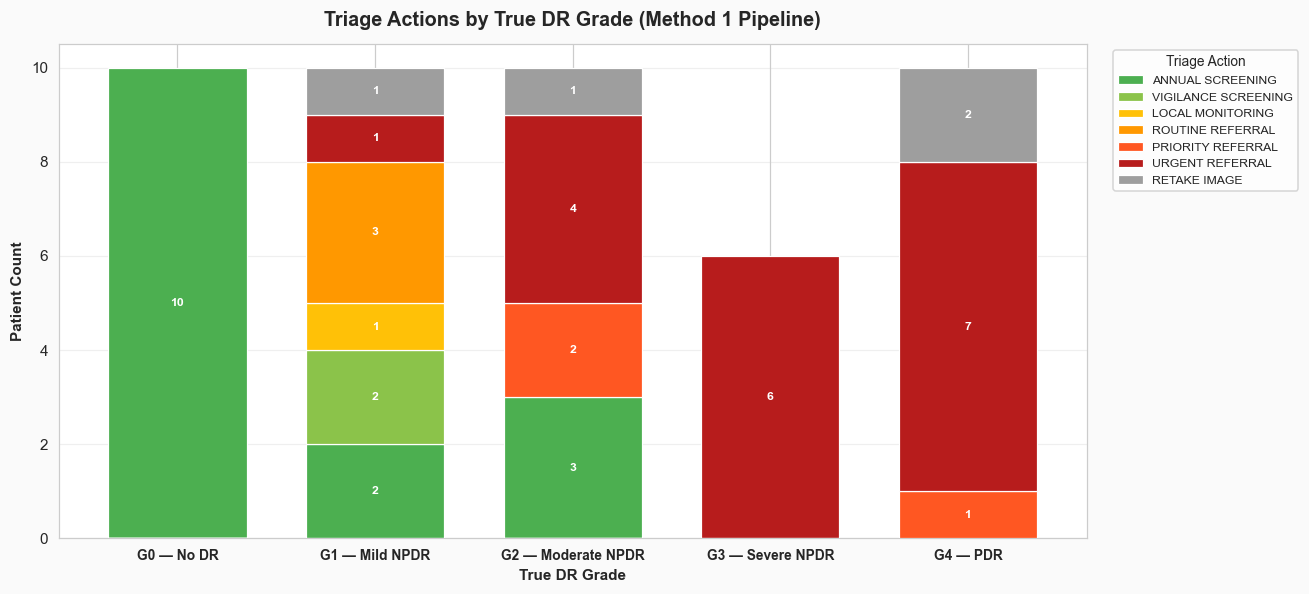

Saved: images/inference_risk_profile.png


In [35]:
results_df['true_grade'] = true_labels
risk_summary = (
    results_df
    .groupby(['true_grade', 'm1_action'])
    .size()
    .reset_index(name='count')
    .pivot(index='true_grade', columns='m1_action', values='count')
    .fillna(0).astype(int)
)

# Reorder columns to match urgency order
ordered_cols = [c for c in ACTION_ORDER if c in risk_summary.columns]
risk_summary = risk_summary[ordered_cols]

print('=== Triage Actions by True Grade (Method 1) ===')
print(risk_summary.to_string())
print()

fig, ax = plt.subplots(figsize=(12, 5.5))
fig.patch.set_facecolor('#FAFAFA')

risk_summary.plot(kind='bar', stacked=True, ax=ax,
                  color=[ACTION_COLORS.get(c, '#999') for c in ordered_cols],
                  edgecolor='white', linewidth=0.8, width=0.7, zorder=3)

ax.set_xlabel('True DR Grade', fontsize=10, fontweight='bold')
ax.set_ylabel('Patient Count', fontsize=10, fontweight='bold')
ax.set_xticklabels([f'G{g} — {DR_LABELS[g]}' for g in risk_summary.index],
                   rotation=0, ha='center', fontsize=9, fontweight='bold')
ax.set_title('Triage Actions by True DR Grade (Method 1 Pipeline)',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(title='Triage Action', bbox_to_anchor=(1.02, 1), loc='upper left',
          fontsize=8, title_fontsize=9, frameon=True, fancybox=True)
ax.grid(axis='y', alpha=0.3, zorder=0)

# add count labels on each bar segment
for container in ax.containers:
    labels = [f'{int(v.get_height())}' if v.get_height() > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center',
                 fontsize=8, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('images/inference_risk_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/inference_risk_profile.png')

## 16. Clinical Safety Analysis

The most critical question for any screening system: **does it miss patients who need urgent care?**
This analysis compares the urgency level assigned by the triage engine (using CNN predictions) against what the engine would assign using ground-truth grades. Under-triage (lower urgency than warranted) is a patient safety concern; over-triage (higher urgency) wastes resources but is clinically safe.

=== Clinical Safety Summary (excluding RETAKE IMAGE) ===
                                     Method 1            Method 2
           Correct Triage         34/42 (81%)         33/42 (79%)
       Over-triage (safe)           1/42 (2%)           0/42 (0%)
      Under-triage (RISK)          7/42 (17%)          9/42 (21%)


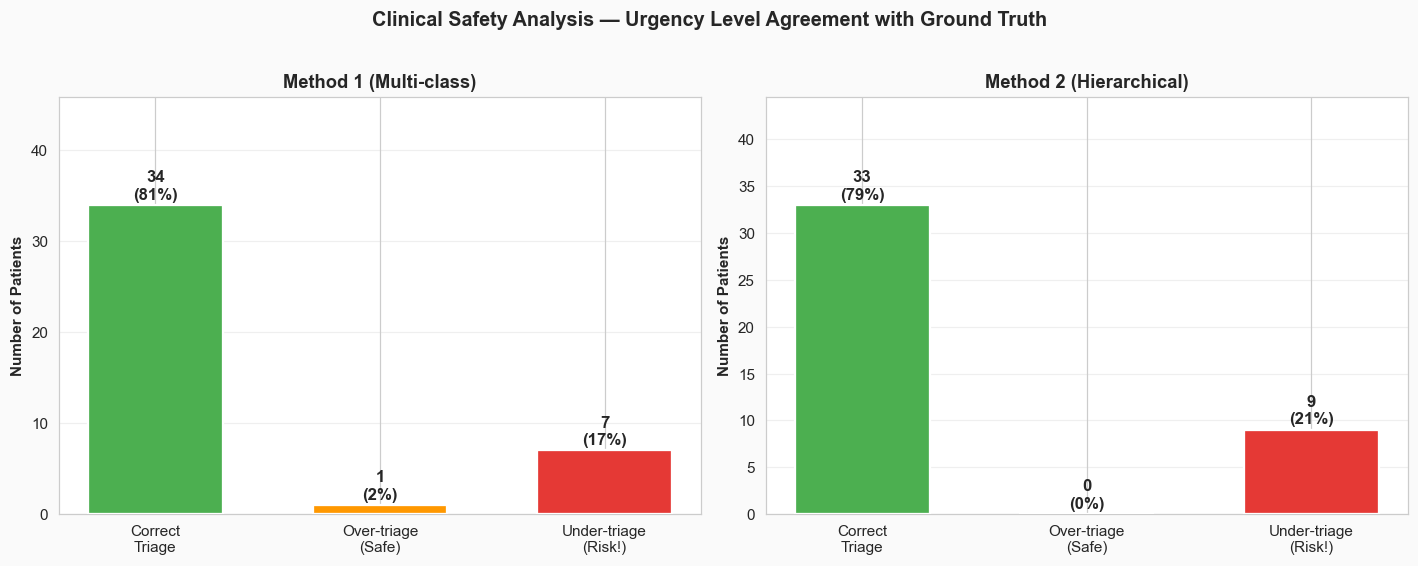

Saved: images/inference_safety_analysis.png


In [36]:
gt_urgency = triage_gt['urgency_level'].values
m1_urgency = triage_m1['urgency_level'].values
m2_urgency = triage_m2['urgency_level'].values

# Exclude RETAKE IMAGE cases (urgency=0 but not a real clinical decision)
retake_mask = triage_gt['action'].values == 'RETAKE IMAGE'

def safety_analysis(pred_urg, gt_urg, mask, method_name):
    valid = ~mask
    p, g = pred_urg[valid], gt_urg[valid]
    correct     = (p == g).sum()
    over_triage = (p > g).sum()
    under_triage = (p < g).sum()
    n = valid.sum()
    return {
        'Method': method_name,
        'Correct Triage': f'{correct}/{n} ({correct/n:.0%})',
        'Over-triage (safe)': f'{over_triage}/{n} ({over_triage/n:.0%})',
        'Under-triage (risk)': f'{under_triage}/{n} ({under_triage/n:.0%})',
        'correct_n': correct, 'over_n': over_triage, 'under_n': under_triage, 'total': n
    }

s1 = safety_analysis(m1_urgency, gt_urgency, retake_mask, 'Method 1')
s2 = safety_analysis(m2_urgency, gt_urgency, retake_mask, 'Method 2')

print('=== Clinical Safety Summary (excluding RETAKE IMAGE) ===')
print(f'{"":>25}  {"Method 1":>18}  {"Method 2":>18}')
print(f'{"Correct Triage":>25}  {s1["Correct Triage"]:>18}  {s2["Correct Triage"]:>18}')
print(f'{"Over-triage (safe)":>25}  {s1["Over-triage (safe)"]:>18}  {s2["Over-triage (safe)"]:>18}')
print(f'{"Under-triage (RISK)":>25}  {s1["Under-triage (risk)"]:>18}  {s2["Under-triage (risk)"]:>18}')

# ── Visualization ─────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#FAFAFA')

for ax, s, title, cmap in [(ax1, s1, 'Method 1 (Multi-class)', ['#4CAF50', '#FF9800', '#E53935']),
                             (ax2, s2, 'Method 2 (Hierarchical)', ['#4CAF50', '#FF9800', '#E53935'])]:
    cats = ['Correct\nTriage', 'Over-triage\n(Safe)', 'Under-triage\n(Risk!)']
    vals = [s['correct_n'], s['over_n'], s['under_n']]
    total = s['total']

    bars = ax.bar(cats, vals, color=cmap, edgecolor='white', linewidth=1.5,
                  width=0.6, zorder=3)
    for bar, v in zip(bars, vals):
        pct = v / total * 100
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{v}\n({pct:.0f}%)', ha='center', va='bottom',
                fontsize=11, fontweight='bold')
    ax.set_ylabel('Number of Patients', fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.35)
    ax.grid(axis='y', alpha=0.3, zorder=0)

plt.suptitle('Clinical Safety Analysis — Urgency Level Agreement with Ground Truth',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/inference_safety_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/inference_safety_analysis.png')

## 17. Clinical Risk Profile & Confidence Distribution

The knowledge base assigns a tabular risk level (LOW / MODERATE / HIGH) based on clinical metadata alone — independent of the CNN prediction. This section visualises how that risk interacts with DR severity, and how confident the CNN is when it gets predictions right vs. wrong.

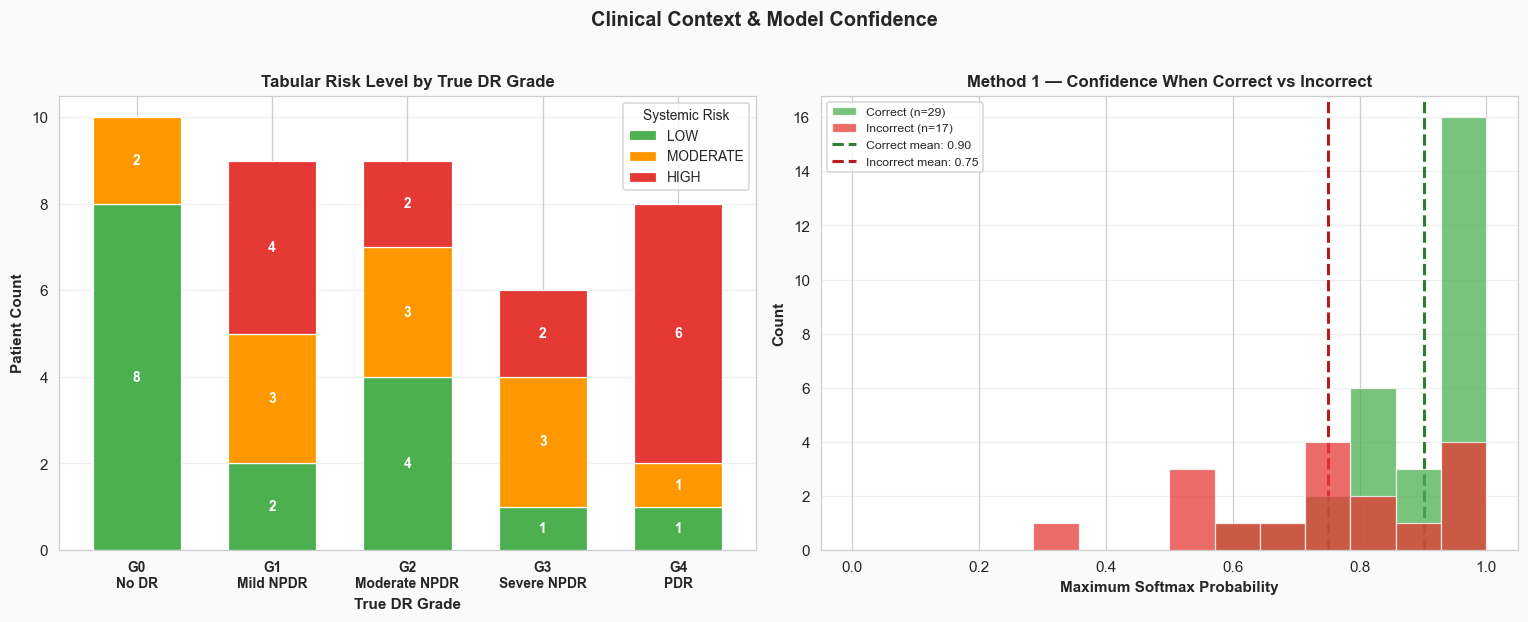

Saved: images/inference_risk_confidence.png


In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor('#FAFAFA')

# Left: Tabular risk by true DR grade 
risk_levels = ['LOW', 'MODERATE', 'HIGH']
risk_colors = {'LOW': '#4CAF50', 'MODERATE': '#FF9800', 'HIGH': '#E53935'}

# Only use non-retake entries
valid_mask = triage_m1['action'].values != 'RETAKE IMAGE'
risk_by_grade = pd.crosstab(
    true_labels[valid_mask],
    triage_m1.loc[valid_mask, 'tabular_risk'],
)
# Reorder columns
risk_by_grade = risk_by_grade[[c for c in risk_levels if c in risk_by_grade.columns]]

risk_by_grade.plot(kind='bar', stacked=True, ax=ax1, width=0.65, zorder=3,
                   color=[risk_colors[c] for c in risk_by_grade.columns],
                   edgecolor='white', linewidth=0.8)
ax1.set_xticklabels([f'G{g}\n{DR_LABELS[g]}' for g in risk_by_grade.index],
                    rotation=0, fontsize=9, fontweight='bold')
ax1.set_xlabel('True DR Grade', fontweight='bold')
ax1.set_ylabel('Patient Count', fontweight='bold')
ax1.set_title('Tabular Risk Level by True DR Grade', fontsize=11, fontweight='bold')
ax1.legend(title='Systemic Risk', fontsize=9, title_fontsize=9)
ax1.grid(axis='y', alpha=0.3, zorder=0)

for container in ax1.containers:
    labels = [f'{int(v.get_height())}' if v.get_height() > 0 else '' for v in container]
    ax1.bar_label(container, labels=labels, label_type='center',
                  fontsize=9, fontweight='bold', color='white')

# Right: Confidence distribution (correct vs incorrect) 
m1_confidence = m1_probs.max(axis=1)
correct_mask  = m1_preds == true_labels

conf_correct = m1_confidence[correct_mask]
conf_wrong   = m1_confidence[~correct_mask]

bins = np.linspace(0, 1, 15)
ax2.hist(conf_correct, bins=bins, alpha=0.75, color='#4CAF50', label=f'Correct (n={len(conf_correct)})',
         edgecolor='white', linewidth=0.8, zorder=3)
ax2.hist(conf_wrong, bins=bins, alpha=0.75, color='#E53935', label=f'Incorrect (n={len(conf_wrong)})',
         edgecolor='white', linewidth=0.8, zorder=3)
ax2.axvline(conf_correct.mean(), color='#2E7D32', ls='--', lw=2,
            label=f'Correct mean: {conf_correct.mean():.2f}')
if len(conf_wrong) > 0:
    ax2.axvline(conf_wrong.mean(), color='#B71C1C', ls='--', lw=2,
                label=f'Incorrect mean: {conf_wrong.mean():.2f}')
ax2.set_xlabel('Maximum Softmax Probability', fontweight='bold')
ax2.set_ylabel('Count', fontweight='bold')
ax2.set_title('Method 1 — Confidence When Correct vs Incorrect',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=8, loc='upper left', frameon=True)
ax2.grid(axis='y', alpha=0.3, zorder=0)

plt.suptitle('Clinical Context & Model Confidence',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/inference_risk_confidence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/inference_risk_confidence.png')

## 18. End-to-End Pipeline Summary Dashboard

A consolidated view of the complete hybrid pipeline performance on the synthetic sample dataset.

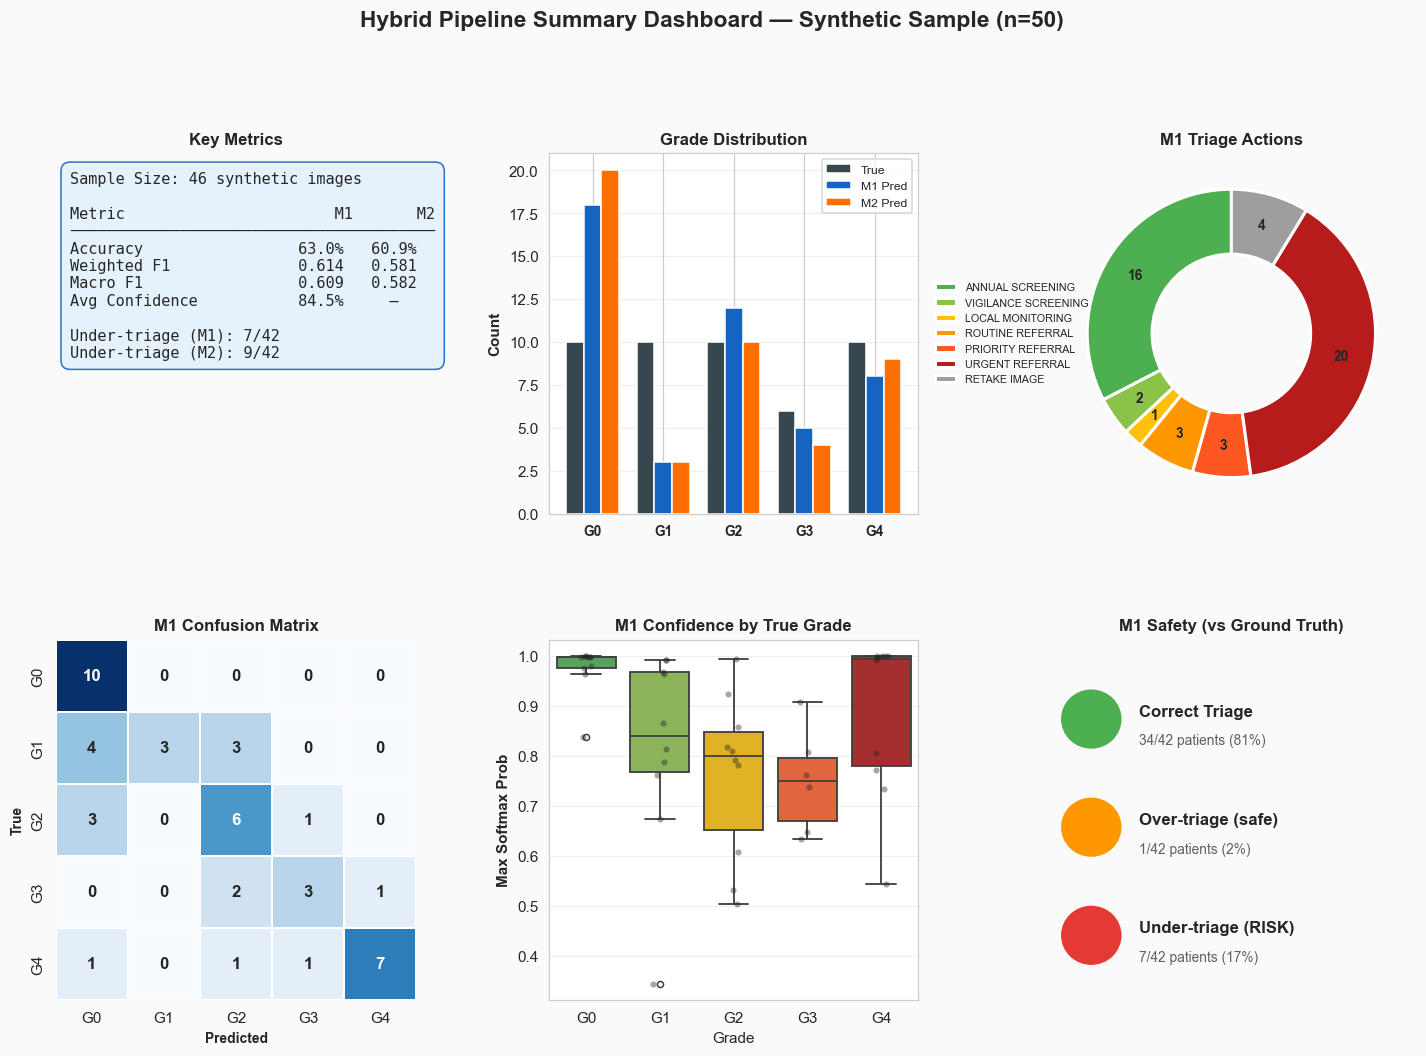

Saved: images/inference_summary_dashboard.png


In [40]:
from sklearn.metrics import f1_score

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#FAFAFA')
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.35)

#  1. KPI metric cards (top-left)
ax_kpi = fig.add_subplot(gs[0, 0])
ax_kpi.axis('off')

m1_acc = (m1_preds == true_labels).mean()
m2_acc = (m2_preds == true_labels).mean()
m1_f1w = f1_score(true_labels, m1_preds, average='weighted', zero_division=0)
m2_f1w = f1_score(true_labels, m2_preds, average='weighted', zero_division=0)
m1_f1m = f1_score(true_labels, m1_preds, average='macro', zero_division=0)
m2_f1m = f1_score(true_labels, m2_preds, average='macro', zero_division=0)

metrics_text = (
    f'Sample Size: {len(true_labels)} synthetic images\n'
    f'\n'
    f'{"Metric":<22} {"M1":>8} {"M2":>8}\n'
    f'{"─"*40}\n'
    f'{"Accuracy":<22} {m1_acc:>7.1%} {m2_acc:>7.1%}\n'
    f'{"Weighted F1":<22} {m1_f1w:>7.3f} {m2_f1w:>7.3f}\n'
    f'{"Macro F1":<22} {m1_f1m:>7.3f} {m2_f1m:>7.3f}\n'
    f'{"Avg Confidence":<22} {m1_confidence.mean():>7.1%}     —\n'
    f'\n'
    f'Under-triage (M1): {s1["under_n"]}/{s1["total"]}\n'
    f'Under-triage (M2): {s2["under_n"]}/{s2["total"]}'
)
ax_kpi.text(0.05, 0.95, metrics_text, transform=ax_kpi.transAxes,
            fontsize=10, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.6', facecolor='#E3F2FD',
                      edgecolor='#1565C0', alpha=0.9))
ax_kpi.set_title('Key Metrics', fontsize=11, fontweight='bold')

# 2. Grade distribution: true vs predicted (top-center) 
ax_dist = fig.add_subplot(gs[0, 1])
x = np.arange(5)
w = 0.25
true_counts = [(true_labels == g).sum() for g in range(5)]
m1_counts   = [(m1_preds == g).sum() for g in range(5)]
m2_counts   = [(m2_preds == g).sum() for g in range(5)]

ax_dist.bar(x - w, true_counts, w, label='True', color='#37474F', edgecolor='white', zorder=3)
ax_dist.bar(x, m1_counts, w, label='M1 Pred', color='#1565C0', edgecolor='white', zorder=3)
ax_dist.bar(x + w, m2_counts, w, label='M2 Pred', color='#FF6F00', edgecolor='white', zorder=3)
ax_dist.set_xticks(x)
ax_dist.set_xticklabels([f'G{g}' for g in range(5)], fontsize=9, fontweight='bold')
ax_dist.set_ylabel('Count', fontweight='bold')
ax_dist.set_title('Grade Distribution', fontsize=11, fontweight='bold')
ax_dist.legend(fontsize=8, loc='upper right')
ax_dist.grid(axis='y', alpha=0.3, zorder=0)

# 3. Triage action donut (top-right) 
ax_donut = fig.add_subplot(gs[0, 2])
m1_action_counts = triage_m1['action'].value_counts()
donut_labels = [a for a in ACTION_ORDER if a in m1_action_counts.index]
donut_vals   = [m1_action_counts[a] for a in donut_labels]
donut_colors = [ACTION_COLORS[a] for a in donut_labels]

wedges, texts, autotexts = ax_donut.pie(
    donut_vals, labels=None, colors=donut_colors,
    autopct=lambda p: f'{int(round(p*50/100))}',
    startangle=90, pctdistance=0.78,
    wedgeprops={'width': 0.45, 'edgecolor': 'white', 'linewidth': 2})
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(9)
ax_donut.legend(donut_labels, loc='center left', bbox_to_anchor=(-0.35, 0.5),
                fontsize=7, frameon=False)
ax_donut.set_title('M1 Triage Actions', fontsize=11, fontweight='bold')

#  4. M1 confusion matrix (bottom-left) 
ax_cm = fig.add_subplot(gs[1, 0])
sns.heatmap(cm_m1, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='white',
            xticklabels=[f'G{g}' for g in range(5)],
            yticklabels=[f'G{g}' for g in range(5)],
            square=True, cbar=False, ax=ax_cm,
            annot_kws={'fontsize': 11, 'fontweight': 'bold'})
ax_cm.set_xlabel('Predicted', fontsize=9, fontweight='bold')
ax_cm.set_ylabel('True', fontsize=9, fontweight='bold')
ax_cm.set_title('M1 Confusion Matrix', fontsize=11, fontweight='bold')

# 5. Confidence box plot by grade (bottom-center) 
ax_box = fig.add_subplot(gs[1, 1])
conf_data = []
for g in range(5):
    mask = true_labels == g
    if mask.sum() > 0:
        for c in m1_confidence[mask]:
            conf_data.append({'Grade': f'G{g}', 'Confidence': c})
conf_df = pd.DataFrame(conf_data)
grade_palette = {f'G{g}': GRADE_COLORS[g] for g in range(5)}
sns.boxplot(data=conf_df, x='Grade', y='Confidence', palette=grade_palette,
            ax=ax_box, linewidth=1.2, fliersize=4, zorder=3)
sns.stripplot(data=conf_df, x='Grade', y='Confidence', color='#212121',
              alpha=0.4, size=4, ax=ax_box, zorder=4)
ax_box.set_ylabel('Max Softmax Prob', fontweight='bold')
ax_box.set_title('M1 Confidence by True Grade', fontsize=11, fontweight='bold')
ax_box.grid(axis='y', alpha=0.3, zorder=0)

# 6. Safety traffic light (bottom-right)
ax_safe = fig.add_subplot(gs[1, 2])
ax_safe.axis('off')

safety_items = [
    ('Correct Triage',    s1['correct_n'],  s1['total'], '#4CAF50'),
    ('Over-triage (safe)', s1['over_n'],    s1['total'], '#FF9800'),
    ('Under-triage (RISK)', s1['under_n'],  s1['total'], '#E53935'),
]
for i, (label, n, total, color) in enumerate(safety_items):
    y = 0.78 - i * 0.30
    ax_safe.add_patch(plt.Circle((0.12, y), 0.08, color=color,
                                  transform=ax_safe.transAxes, zorder=5))
    ax_safe.text(0.12, y, f'{n}', transform=ax_safe.transAxes,
                 ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax_safe.text(0.25, y + 0.02, f'{label}', transform=ax_safe.transAxes,
                 fontsize=11, fontweight='bold', va='center')
    ax_safe.text(0.25, y - 0.06, f'{n}/{total} patients ({n/total:.0%})',
                 transform=ax_safe.transAxes, fontsize=9, color='#616161', va='center')

ax_safe.set_title('M1 Safety (vs Ground Truth)', fontsize=11, fontweight='bold')

plt.suptitle('Hybrid Pipeline Summary Dashboard — Synthetic Sample (n=50)',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('images/inference_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/inference_summary_dashboard.png')